In [131]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc, Wedge
import numpy as np
import matplotlib.image as mpimg  
import seaborn as sns
import matplotlib.patches as patches
from matplotlib.path import Path
import matplotlib.ticker as mtick

In [2]:
shots_df = pd.read_csv('C:/Users/pitom/OneDrive/Desktop/materiale uni/data-vis/esame/shots_team_year.csv')

In [3]:

shots_df = shots_df[(shots_df['LOC_X'] != 0) | (shots_df['LOC_Y'] != 0)]
shots_df['SHOT_DISTANCE'] = np.sqrt(shots_df['LOC_X']**2 + shots_df['LOC_Y']**2)
shots_df['IN_PAINT'] = (shots_df['LOC_X'].abs() <= 80) & (shots_df['LOC_Y'] <= 142.5)
shots_df['IS_THREE'] = (
    ((shots_df['LOC_X'].abs() > 220) & (shots_df['LOC_Y'] <= 89)) |  # angoli
    (shots_df['SHOT_DISTANCE'] > 237.5)  # distanza > 23.75 piedi
)
shots_df['MID_RANGE'] = ~(shots_df['IN_PAINT'] | shots_df['IS_THREE'])
shots_df['SHOT_TYPE'] = np.select(
    [
        shots_df['IN_PAINT'],
        shots_df['IS_THREE'],
        shots_df['MID_RANGE']
    ],
    [
        'In the Paint',
        'Three Points',
        'Mid Range'
    ],
    default='Other'
)
print(shots_df[(shots_df['LOC_X'] == 0) & (shots_df['LOC_Y'] == 0)].shape[0])
shots_df.head()

0


,TEAM_NAME,LOC_X,LOC_Y,SEASON,SHOT_DISTANCE,IN_PAINT,IS_THREE,MID_RANGE,SHOT_TYPE
1,Chicago Bulls,45,148,1996-97,154.690013,False,False,True,Mid Range
2,Boston Celtics,163,122,1996-97,203.600098,False,False,True,Mid Range
6,Chicago Bulls,-12,75,1996-97,75.953933,True,False,False,In the Paint
8,Boston Celtics,-244,-16,1996-97,244.524027,False,True,False,Three Points
10,Chicago Bulls,205,101,1996-97,228.530086,False,False,True,Mid Range


In [4]:
nba_finals = [
    ("Chicago Bulls", "Seattle SuperSonics"),   
    ("Chicago Bulls", "Utah Jazz"),             
    ("Chicago Bulls", "Utah Jazz"),             
    ("San Antonio Spurs", "New York Knicks"),   
    ("Los Angeles Lakers", "Indiana Pacers"),   
    ("Los Angeles Lakers", "Philadelphia 76ers"),
    ("Los Angeles Lakers", "New Jersey Nets"),  
    ("San Antonio Spurs", "New Jersey Nets"),   
    ("Detroit Pistons", "Los Angeles Lakers"),  
    ("San Antonio Spurs", "Detroit Pistons"),   
    ("Miami Heat", "Dallas Mavericks"),         
    ("San Antonio Spurs", "Cleveland Cavaliers"),
    ("Boston Celtics", "Los Angeles Lakers"),   
    ("Los Angeles Lakers", "Orlando Magic"),    
    ("Los Angeles Lakers", "Boston Celtics"),   
    ("Dallas Mavericks", "Miami Heat"),         
    ("Miami Heat", "Oklahoma City Thunder"),    
    ("Miami Heat", "San Antonio Spurs"),        
    ("San Antonio Spurs", "Miami Heat"),        
    ("Golden State Warriors", "Cleveland Cavaliers"), 
    ("Cleveland Cavaliers", "Golden State Warriors"), 
    ("Golden State Warriors", "Cleveland Cavaliers"), 
    ("Golden State Warriors", "Cleveland Cavaliers"), 
    ("Toronto Raptors", "Golden State Warriors"),     
    ("Los Angeles Lakers", "Miami Heat"),      
    ("Milwaukee Bucks", "Phoenix Suns"),        
    ("Golden State Warriors", "Boston Celtics"),
    ("Denver Nuggets", "Miami Heat"),           
    ("Boston Celtics", "Dallas Mavericks")      
]

In [5]:
seasons = [f"{year}-{str(year+1)[2:]}" for year in range(1996, 2025)]

finals_teams_per_season = [
    {'SEASON': season, 'TEAM_NAME': winner}
    for season, (winner, _) in zip(seasons, nba_finals)
] + [
    {'SEASON': season, 'TEAM_NAME': finalist}
    for season, (_, finalist) in zip(seasons, nba_finals)
]


finalists_df = pd.DataFrame(finals_teams_per_season)
finals_shots = shots_df.merge(finalists_df, on=['SEASON', 'TEAM_NAME'])
finals_shots.head()

,TEAM_NAME,LOC_X,LOC_Y,SEASON,SHOT_DISTANCE,IN_PAINT,IS_THREE,MID_RANGE,SHOT_TYPE
0,Chicago Bulls,45,148,1996-97,154.690013,False,False,True,Mid Range
1,Chicago Bulls,-12,75,1996-97,75.953933,True,False,False,In the Paint
2,Chicago Bulls,205,101,1996-97,228.530086,False,False,True,Mid Range
3,Chicago Bulls,64,168,1996-97,179.777640,False,False,True,Mid Range
4,Chicago Bulls,-231,86,1996-97,246.489351,False,True,False,Three Points


In [6]:
def assign_zone(row):
    x, y = row['LOC_X'], row['LOC_Y']

    if row['IS_THREE']:
        if abs(x) > 220 and y < 100:
            return 'Corner 3 (L)' if x < 0 else 'Corner 3 (R)'
        elif abs(x) < 80:
            return 'Top 3'
        else:
            return 'Wing 3 (L)' if x < 0 else 'Wing 3 (R)'

    elif row['MID_RANGE']:
        if abs(x) < 80:
            return 'Top Mid'
        else:
            return 'Wing Mid (L)' if x < 0 else 'Wing Mid (R)'

    elif row['IN_PAINT']:
        if np.hypot(x, y) < 40:
            return 'Restricted Area'
        elif abs(x) < 60:
            return 'Paint Center'
        else:
            return 'Paint Wing (L)' if x < 0 else 'Paint Wing (R)'

    return 'Other'


In [7]:
finals_shots['ZONE'] = finals_shots.apply(assign_zone, axis=1)
finals_shots.head()

,TEAM_NAME,LOC_X,LOC_Y,SEASON,SHOT_DISTANCE,IN_PAINT,IS_THREE,MID_RANGE,SHOT_TYPE,ZONE
0,Chicago Bulls,45,148,1996-97,154.690013,False,False,True,Mid Range,Top Mid
1,Chicago Bulls,-12,75,1996-97,75.953933,True,False,False,In the Paint,Paint Center
2,Chicago Bulls,205,101,1996-97,228.530086,False,False,True,Mid Range,Wing Mid (R)
3,Chicago Bulls,64,168,1996-97,179.777640,False,False,True,Mid Range,Top Mid
4,Chicago Bulls,-231,86,1996-97,246.489351,False,True,False,Three Points,Corner 3 (L)


In [14]:
def make_shot_heatmap(shots_df,Teams=0, stagioni_scelte=0, examples = 0,ax=None):
    def draw_court(ax=None, color='black', lw=2, outer_lines=False):
        if ax is None:
            ax = plt.gca()
        hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
        backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
        outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
        inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
        free_throw_top = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)
        free_throw_bottom = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
        restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
        corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
        corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
        three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
        center_circle = Arc((0, 422.5), 120, 120, theta1=0, theta2=360, linewidth=lw, color=color)
        court_elements = [hoop, backboard, outer_box, inner_box,
                          free_throw_top, free_throw_bottom, restricted,
                          corner_three_a, corner_three_b, three_arc,
                          center_circle]
        if outer_lines:
            outer = Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False)
            court_elements.append(outer)
        for element in court_elements:
            ax.add_patch(element)
        return ax

    if examples == 0:
        sample_df = shots_df
    elif examples < 50000:
        sample_df = shots_df.sample(50000)
    else:
        sample_df = shots_df.sample(examples)

    if stagioni_scelte != 0:
        df = sample_df[sample_df['SEASON'].isin(stagioni_scelte)]  
    else:
        df = sample_df

    if Teams != 0:
        df = df[df['TEAM_NAME'].isin(Teams)]

    # Crea fig solo se ax non è passato
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 9))
    else:
        fig = ax.figure

#E6BE8A (legno chiaro)
#D2B48C (tan)
#DEB887 (burlywood)
#C19A6B (wood)
    hb = ax.hexbin(
        x=df['LOC_X'],
        y=df['LOC_Y'],
        gridsize=70,
        extent=(-250, 250, -50, 470),
        cmap='Reds',
        bins='log',
        mincnt=1,
        alpha= 0.8,
        vmax=1000
    )



    draw_court(ax, outer_lines=True)

    ax.axis('off')
    ax.set_title(f"Heatmap {stagioni_scelte}", fontsize=15)

    if hb.get_array().size > 0 and np.all(np.isfinite(hb.get_array())):
        cbar = fig.colorbar(hb, ax=ax)
        cbar.set_label('Numero di tiri (log)', fontsize=13)
    
    return fig, ax

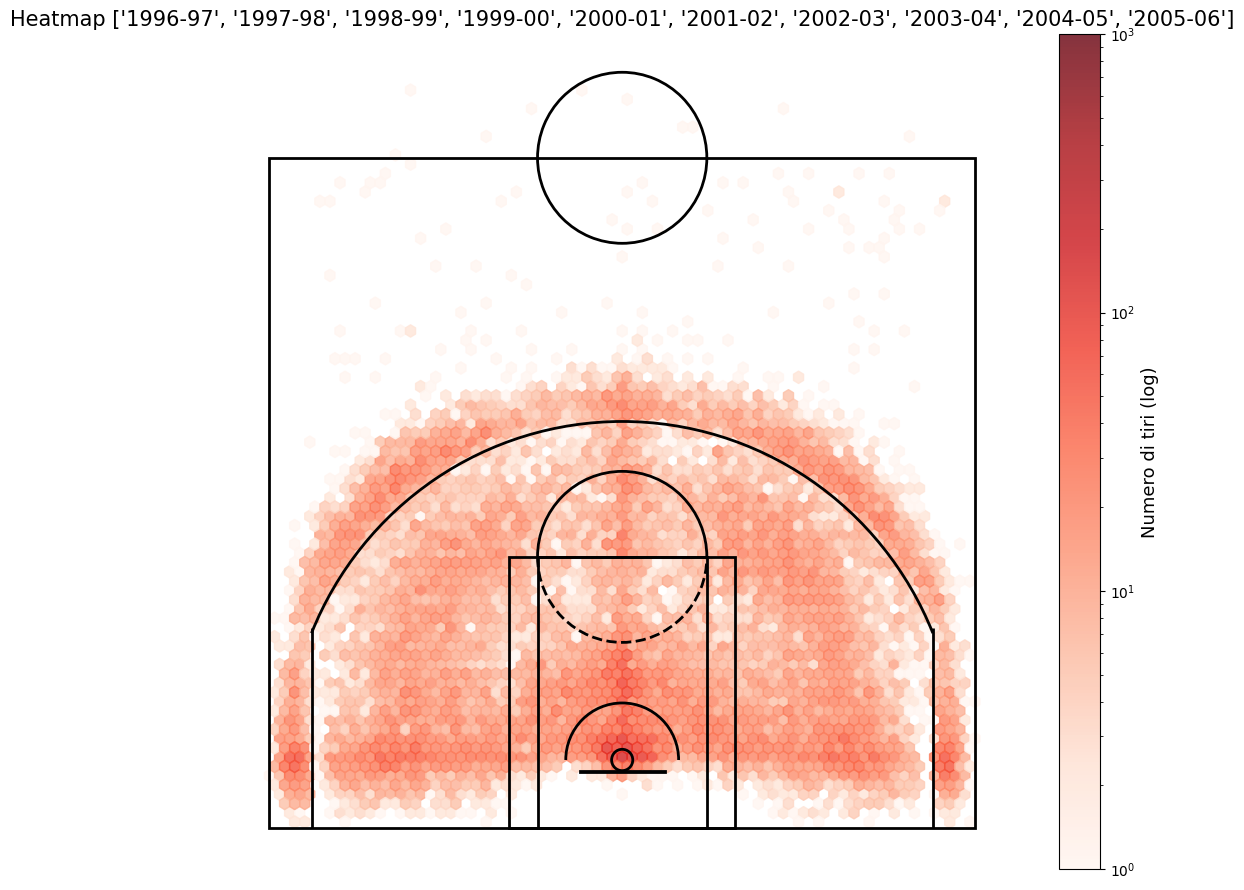

In [20]:
seasons = [f"{year}-{str(year+1)[2:]}" for year in range(1996, 2006)]
_, ax = make_shot_heatmap(finals_shots,stagioni_scelte=seasons, examples=100000)

plt.tight_layout()
plt.show()

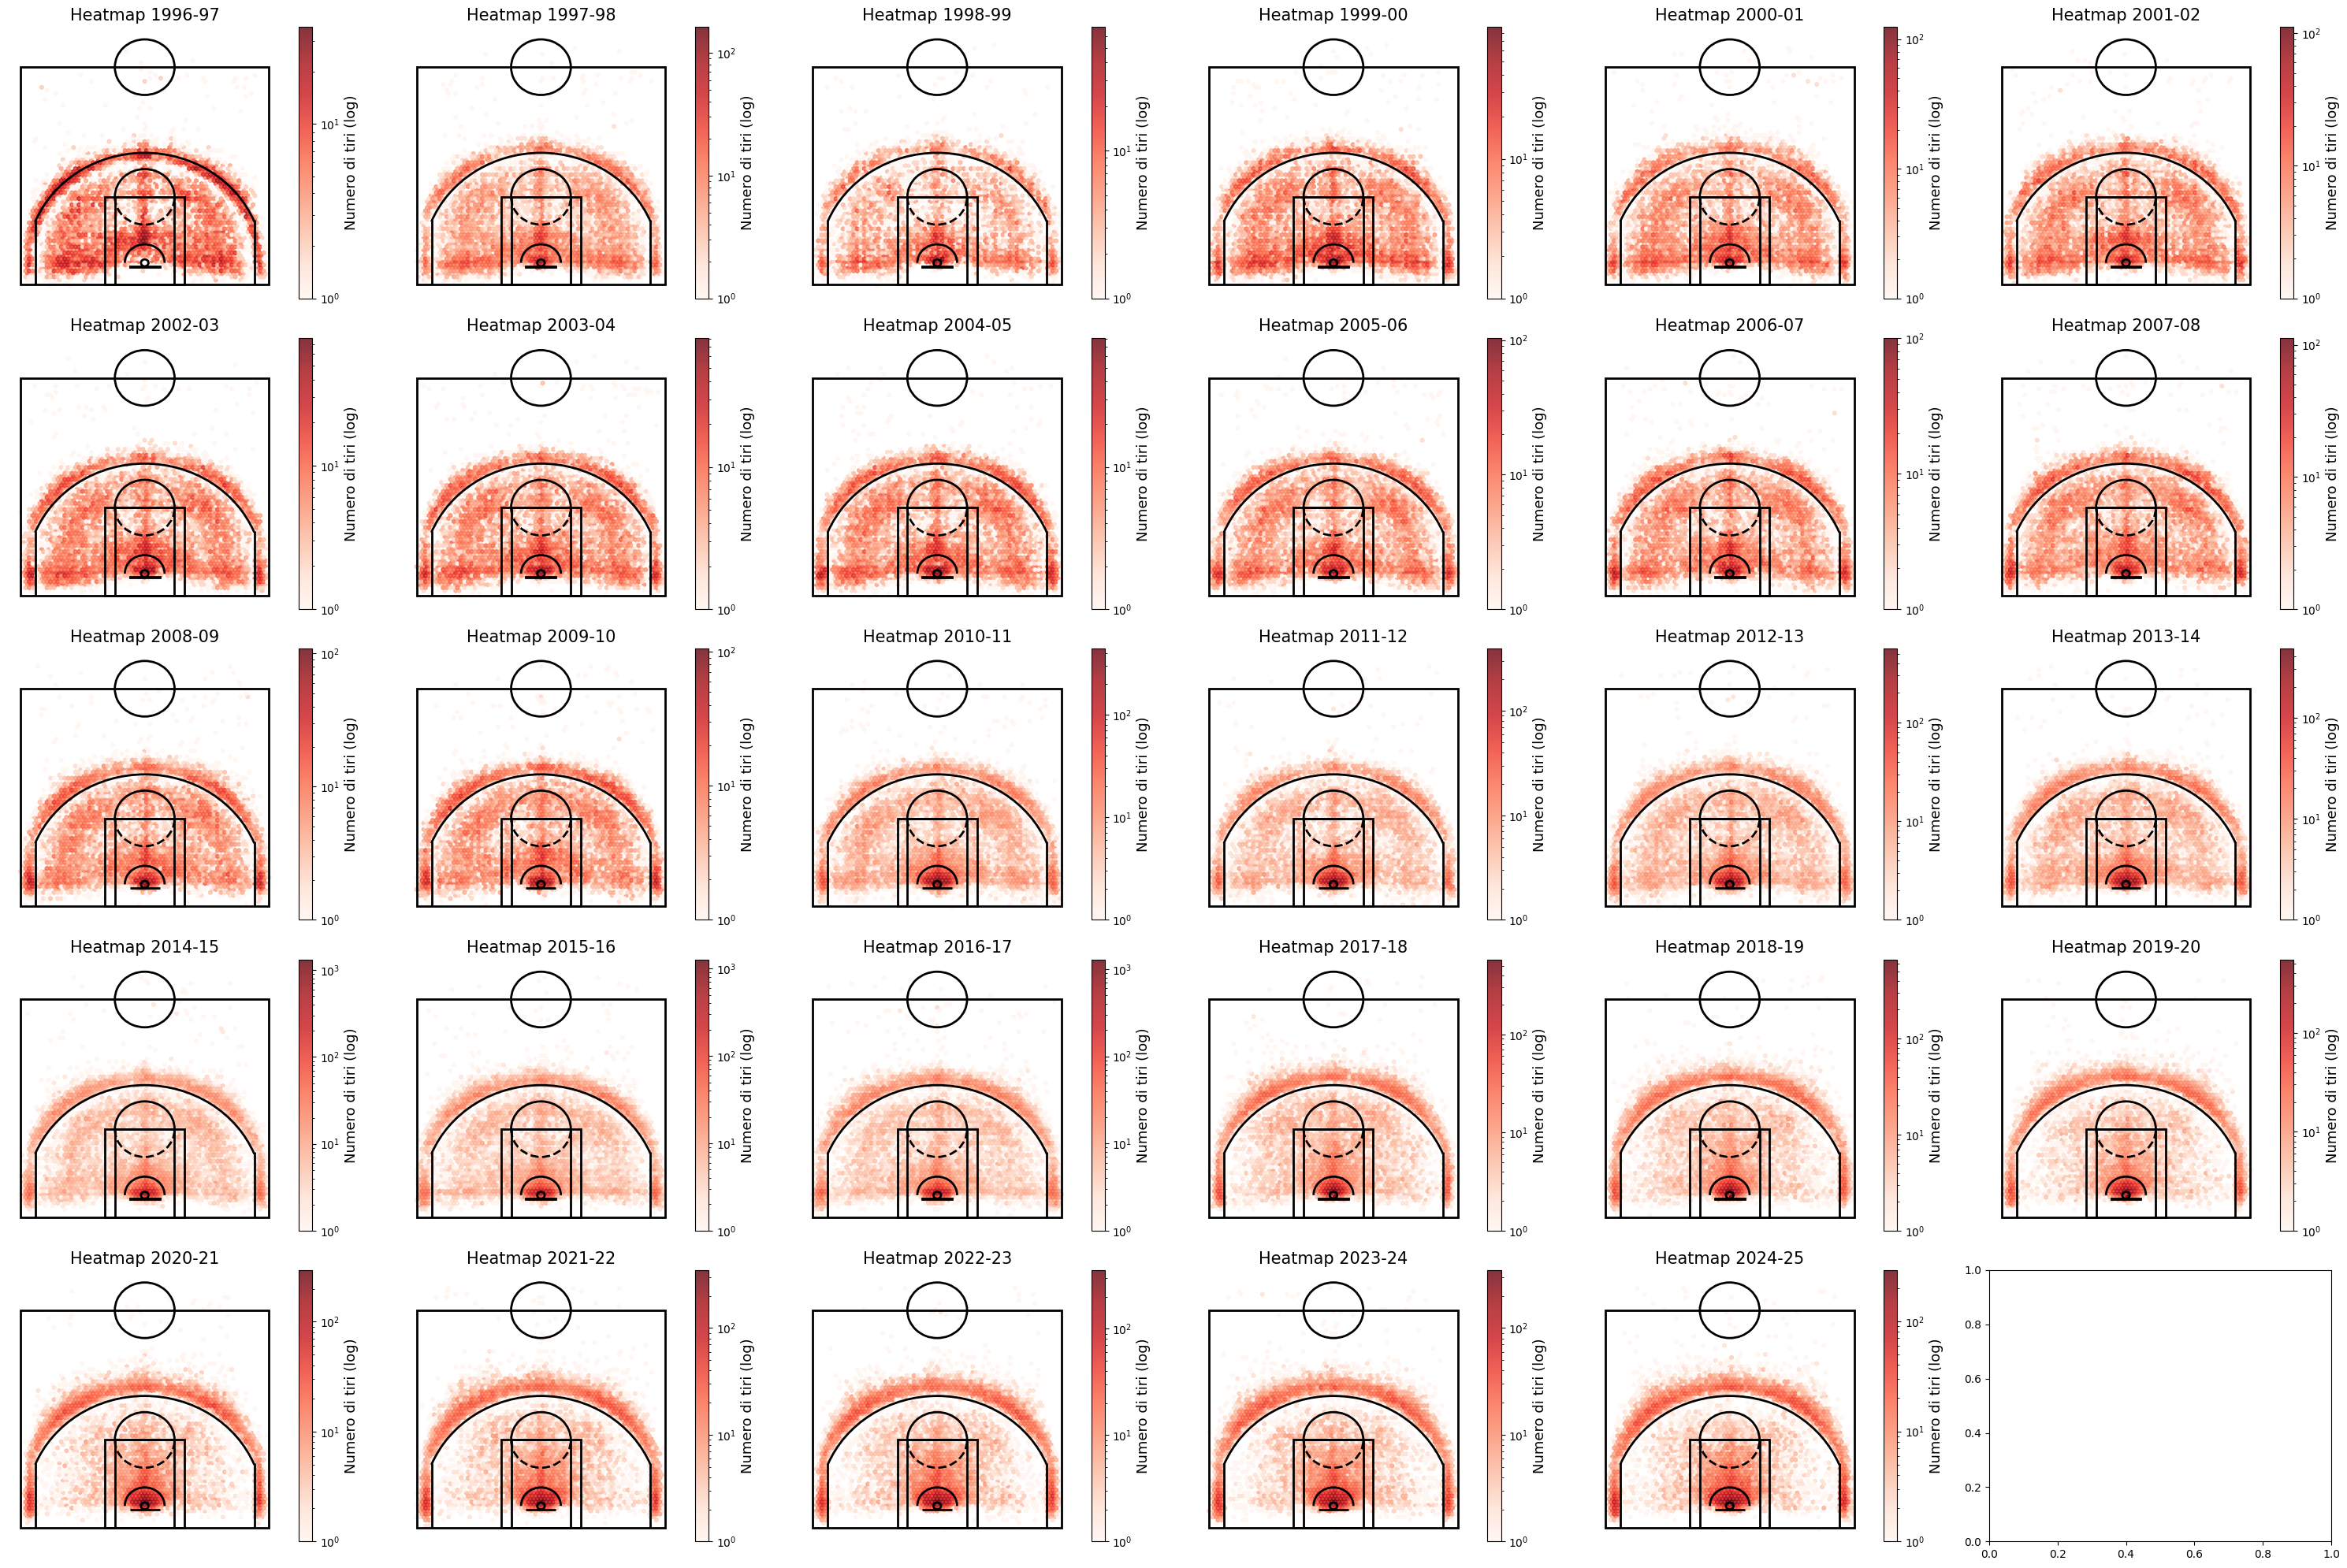

In [ ]:
seasons = [f"{year}-{str(year+1)[2:]}" for year in range(1996, 2025)]
fig, axs = plt.subplots(5,6 , figsize=(30, 20))  # 25 stagioni

for i, season in enumerate(seasons):
    row, col = divmod(i, 6)
    _, ax = make_shot_heatmap(shots_df,stagioni_scelte=season, examples=500000,ax=axs[row][col])

plt.tight_layout()
plt.show()

In [111]:

counts = finals_shots.groupby(['SEASON', 'SHOT_TYPE']).size().unstack(fill_value=0)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
percentages = percentages[['Mid Range','In the Paint', 'Three Points']]
percentages

SHOT_TYPE,Mid Range,In the Paint,Three Points
SEASON,,,
1996-97,65.319982,19.060773,15.619245
1997-98,59.656604,22.197284,18.146112
1998-99,54.672456,26.656598,18.670946
1999-00,49.322231,33.249419,17.428350
2000-01,43.367914,34.105224,22.526862
2001-02,49.548811,28.394176,22.057014
2002-03,49.167452,25.709498,25.123050
2003-04,44.603601,32.985179,22.411221
2004-05,46.603630,22.312792,31.083578


C:\Users\pitom\AppData\Local\Temp\ipykernel_29552\1315334245.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.1f}%' for tick in ax.get_yticks()], fontsize=14, fontweight='bold')


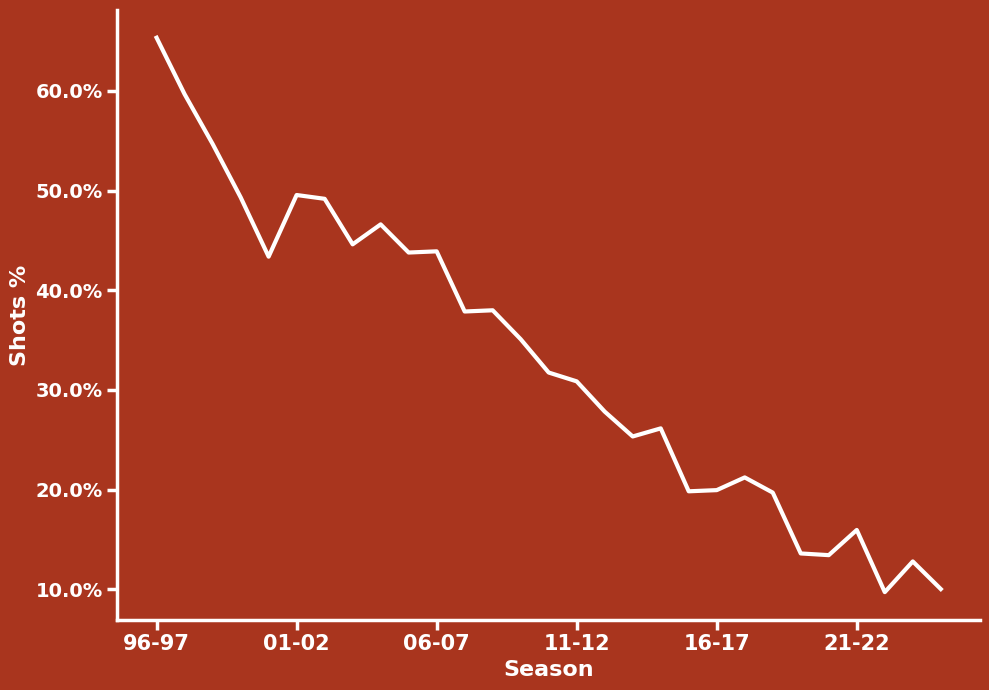

In [158]:
categories = percentages.columns
seasons = percentages.index
fig, ax = plt.subplots(figsize=(10, 7),facecolor='#a9351e')
ax.set_facecolor('#a9351e')
ax.plot(seasons, percentages['Mid Range'], color='white', linewidth= 3)

selected_ticks = seasons[::len(seasons)//5]  
ax.set_xticks(selected_ticks)
ax.set_xticklabels([s[-5:] for s in selected_ticks], fontsize=15, fontweight='bold')
ax.set_yticklabels([f'{tick:.1f}%' for tick in ax.get_yticks()], fontsize=14, fontweight='bold')

ax.tick_params(axis='y', labelsize=14) 
ax.tick_params(axis='both', width=2.5, length=7)

ax.set_ylabel("Shots %", fontsize=16, fontweight='bold',color='white')
ax.set_xlabel("Season", fontsize=16, fontweight='bold' ,color='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2.5)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_linewidth(2.5)
ax.spines['bottom'].set_color('white')

ax.tick_params(colors='white')  # tick bianchi
ax.yaxis.label.set_color('white')
ax.xaxis.label.set_color('white')

plt.tight_layout()
plt.show()

In [21]:
def delta_shots_by_position(shots_df, range_1, range_2, teams=None):
    from collections import defaultdict
    df = shots_df[
        shots_df['SEASON'].between(range_1[0], range_1[1]) |
        shots_df['SEASON'].between(range_2[0], range_2[1])
    ]
    if teams:
        df = df[df['TEAM_NAME'].isin(teams)]

    df = df.copy()
    df['SEASON_START'] = df['SEASON'].str.slice(0, 4).astype(int)
    df['BEFORE_AFTER'] = np.where(
        df['SEASON'].between(range_1[0], range_1[1]), 'before',
        np.where(df['SEASON'].between(range_2[0], range_2[1]), 'after', 'ignore')
    )
    df['POS'] = df[['LOC_X', 'LOC_Y']].agg(tuple, axis=1)
    counts = df.groupby(['POS', 'BEFORE_AFTER']).size().unstack(fill_value=0)
    counts['DELTA'] = counts.get('after', 0) - counts.get('before', 0)
    result_df = counts['DELTA'].reset_index().rename(columns={'DELTA': 'DELTA'})
    result_df[['LOC_X', 'LOC_Y']] = pd.DataFrame(result_df['POS'].tolist(), index=result_df.index)
    result_df.drop(columns='POS', inplace=True)
    return result_df


In [87]:
df = delta_shots_by_position (finals_shots, range_1=('1996-97', '2003-04'),range_2=('2019-20', '2024-25'),)
df.to_csv('delta_shots.csv', index=False)

In [89]:
print(df['DELTA'].describe())
print("Valori positivi:", (df['DELTA'] > 0).sum())
print("Valori negativi:", (df['DELTA'] < 0).sum())

count    66169.000000
mean         0.113074
std          2.986686
min        -54.000000
25%         -1.000000
50%          0.000000
75%          1.000000
max        322.000000
Name: DELTA, dtype: float64
Valori positivi: 30586
Valori negativi: 30917


count    66169.000000
mean         0.014655
std          0.155856
min         -0.691191
25%         -0.020781
50%         -0.018552
75%         -0.018552
max          1.000000
Name: transformed_delta, dtype: float64
Valori positivi: 16451
Valori negativi: 49718


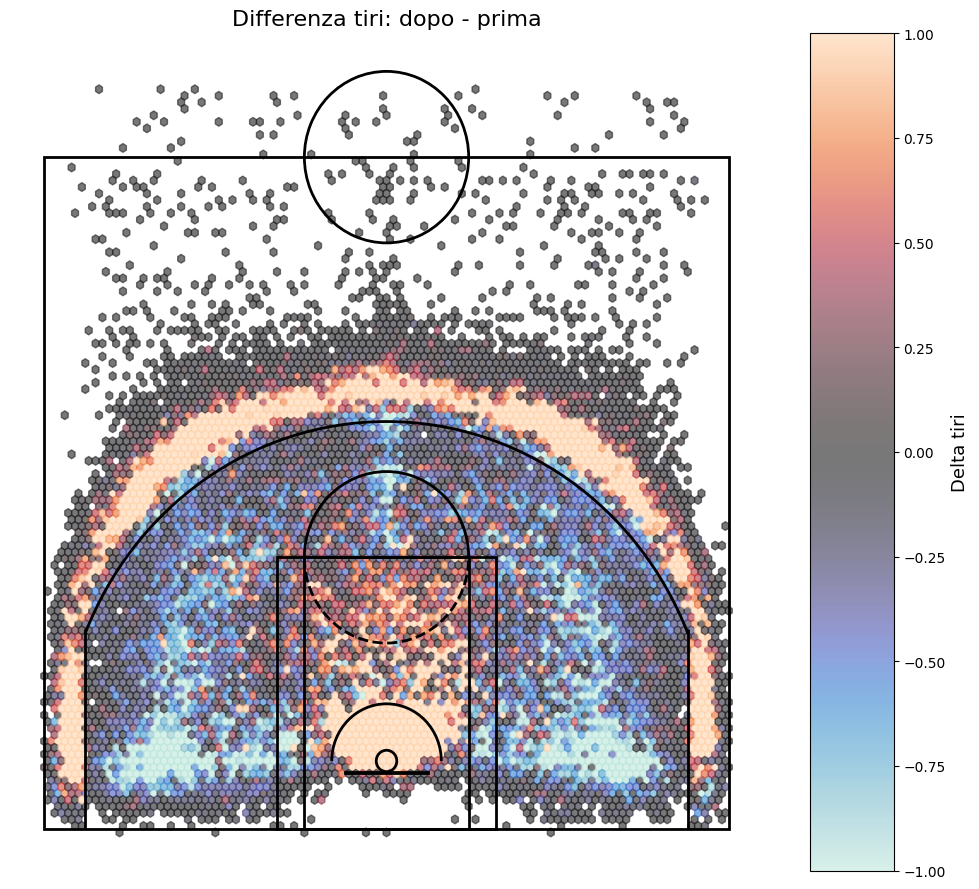

In [159]:
def draw_court(ax=None, color='black', lw=2, outer_lines=False):
    if ax is None:
        ax = plt.gca()
        
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    free_throw_top = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color)
    free_throw_bottom = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    center_circle = Arc((0, 422.5), 120, 120, theta1=0, theta2=360, linewidth=lw, color=color)

    court_elements = [hoop, backboard, outer_box, inner_box,
                      free_throw_top, free_throw_bottom, restricted,
                      corner_three_a, corner_three_b, three_arc, center_circle]

    if outer_lines:
        outer = Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False)
        court_elements.append(outer)

    for element in court_elements:
        ax.add_patch(element)

    return ax

def normalization(x):
    mean_val = np.mean(x)
    centered = x - mean_val
    centered = np.where(centered == 0, 1e-5, centered)
    transformed = np.sign(centered) * np.log(np.abs(centered))
    max_val = np.max(np.abs(transformed))
    normalized = transformed / max_val
    return normalized

def plot_delta_heatmap(df):
    fig, ax = plt.subplots(figsize=(10, 9))
    df['transformed_delta'] = normalization(df['DELTA'])
    print(df['transformed_delta'].describe())
    print("Valori positivi:", (df['transformed_delta'] > 0).sum())
    print("Valori negativi:", (df['transformed_delta'] < 0).sum())

    hb = ax.hexbin(
        x=df['LOC_X'],
        y=df['LOC_Y'],
        C=df['transformed_delta'],
        gridsize=100,
        extent=(-250, 250, -50, 470),
        cmap='icefire', 
        alpha=0.6,
        reduce_C_function=np.sum,
        vmin = -1,
        vmax = 1
        )

    draw_court(ax, outer_lines=True)
    ax.axis('off')
    ax.set_title('Differenza tiri: dopo - prima', fontsize=16)

    cbar = fig.colorbar(hb, ax=ax, aspect= 10)
    cbar.set_label('Delta tiri', fontsize=13)

    plt.tight_layout()
    plt.show()

plot_delta_heatmap(df)


C:\Users\pitom\AppData\Local\Temp\ipykernel_29552\4254044930.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.1, 0, 1, 1])  # lascia spazio a sinistra per la colorbar


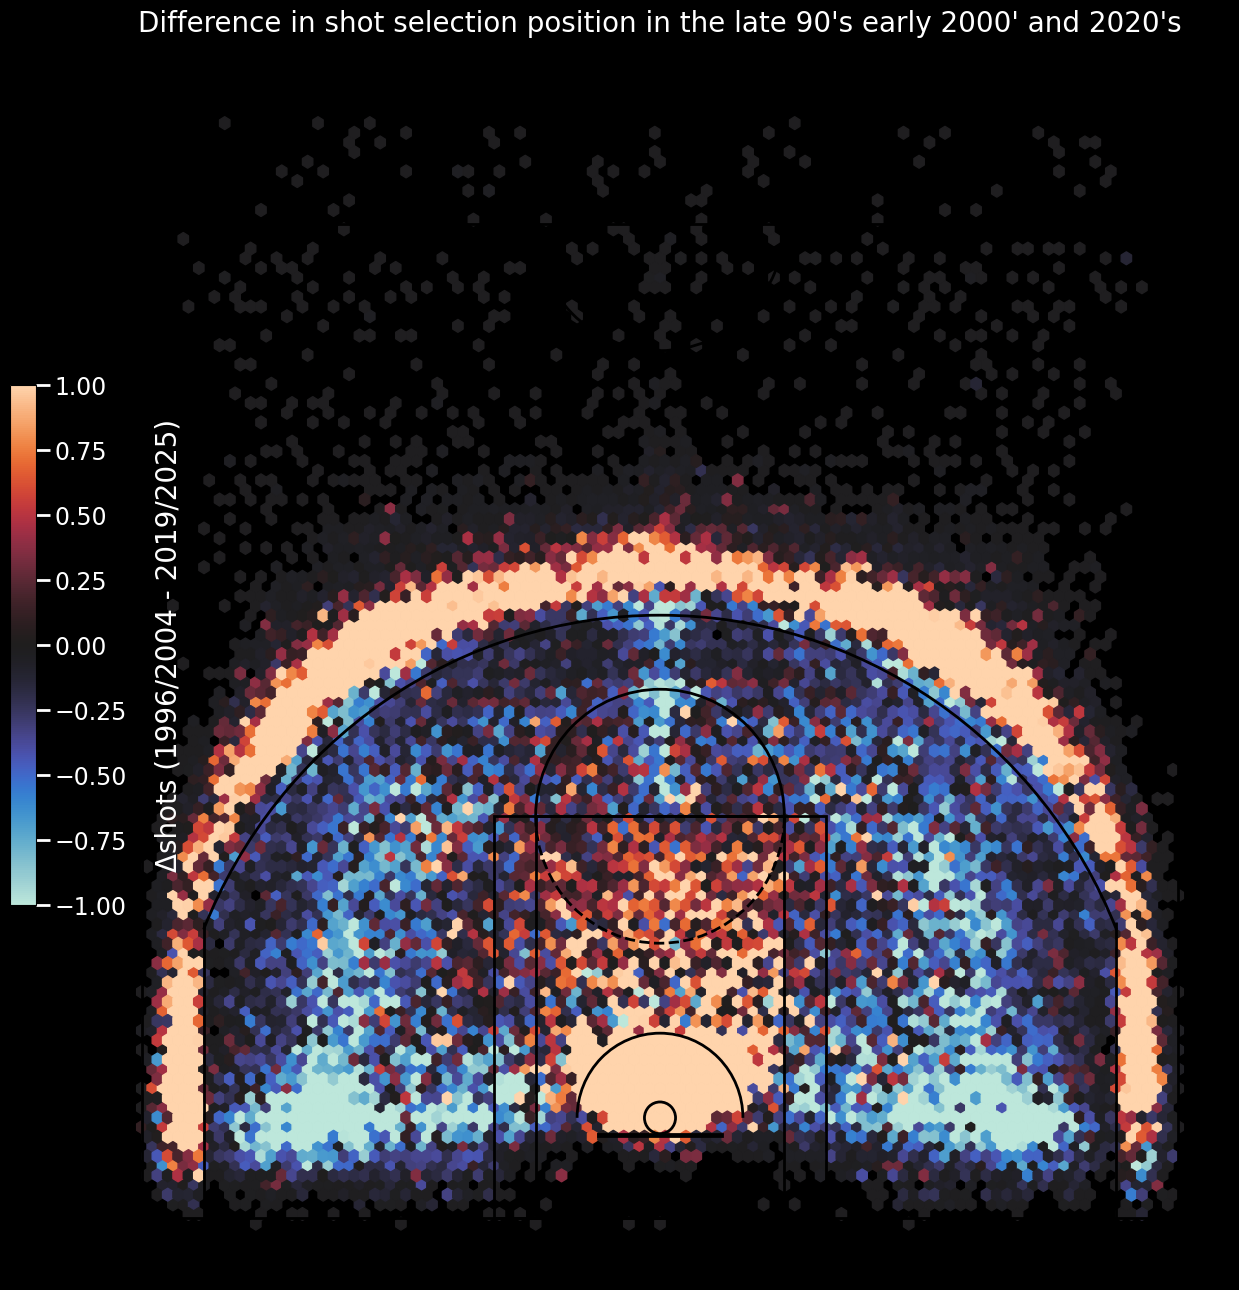

In [ ]:
def plot_delta_heatmap(df):
    fig, ax = plt.subplots(figsize=(13, 13), facecolor='black')
    ax.set_facecolor('black')

    df['transformed_delta'] = normalization(df['DELTA'])

    hb = ax.hexbin(
        x=df['LOC_X'],
        y=df['LOC_Y'],
        C=df['transformed_delta'],
        gridsize=100,
        extent=(-250, 250, -50, 470),
        cmap='icefire', 
        alpha=1,
        reduce_C_function=np.sum,
        vmin=-1,
        vmax=1
    )

    draw_court(ax, outer_lines=True)
    ax.axis('off')
    ax.set_title("Difference in shot selection position in the late 90's early 2000' and 2020's", fontsize=20, color='white')

    #Aggiungi un asse per la colorbar a sinistra
    cbar_ax = fig.add_axes([0.05, 0.15, 0.02, 0.7], aspect=10)  
    cbar = fig.colorbar(hb, cax=cbar_ax, aspect=10)
    cbar.set_label('Δshots (1996/2004 - 2019/2025)', fontsize=20, color='white', labelpad=20)
    cbar.ax.tick_params(colors='white', labelsize=17, length=10, width=2)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white', fontsize=17)

    plt.tight_layout(rect=[0.1, 0, 1, 1])  # lascia spazio a sinistra per la colorbar
    plt.show()
plot_delta_heatmap(df)

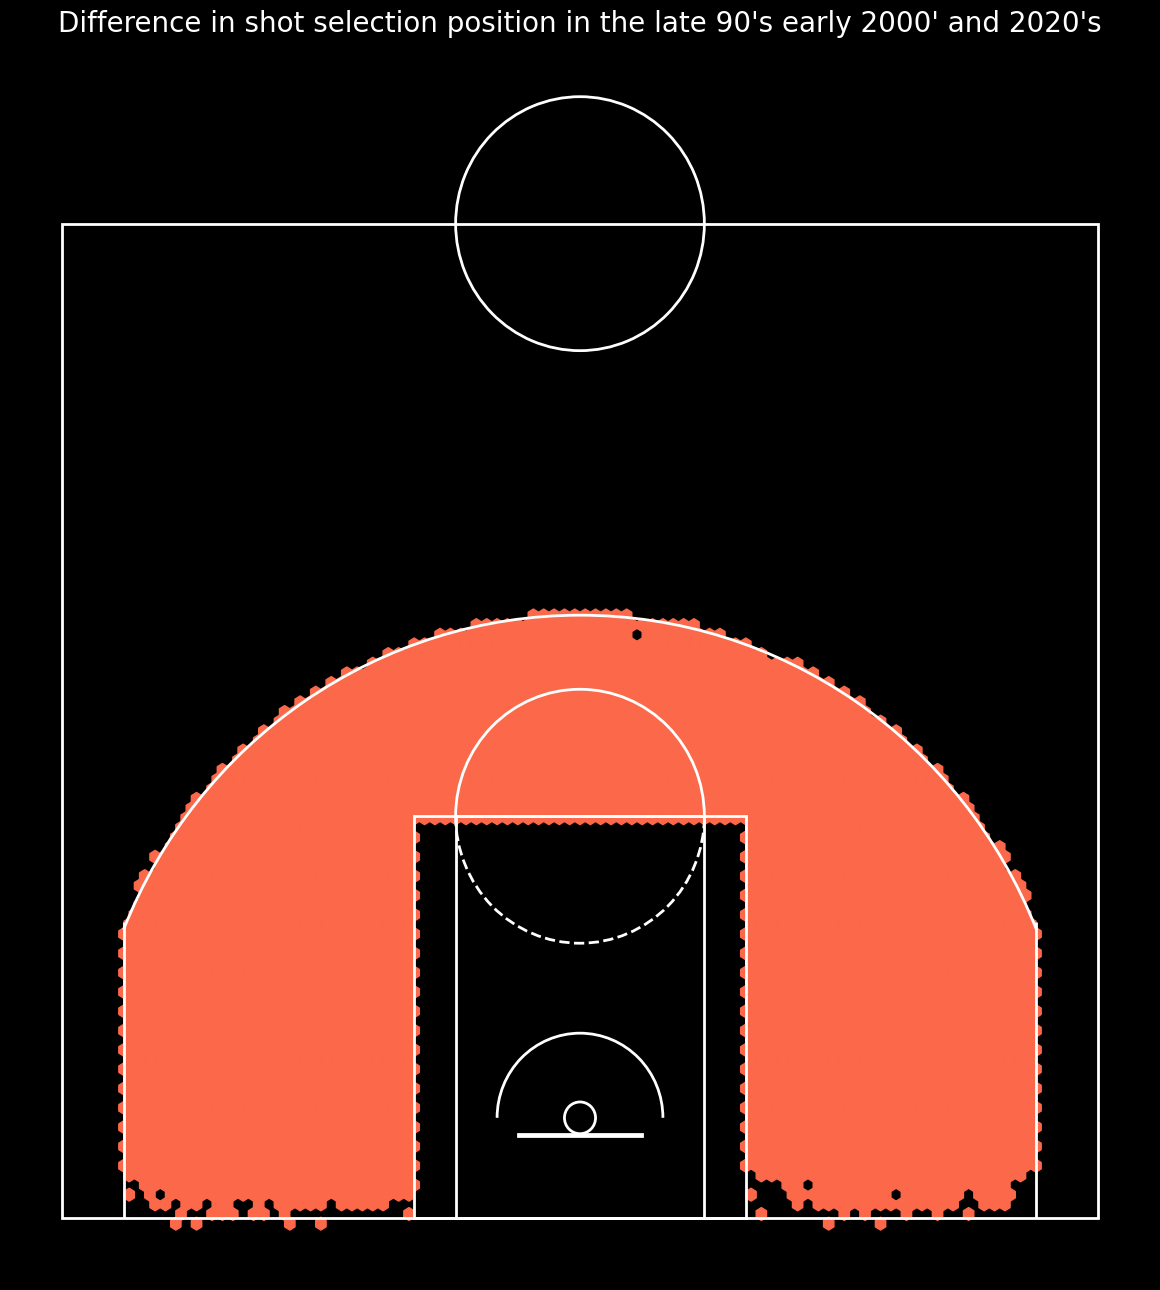

In [172]:
def draw_court(ax=None, color='white', lw=2, outer_lines=False):
    if ax is None:
        ax = plt.gca()
        
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    free_throw_top = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color)
    free_throw_bottom = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    center_circle = Arc((0, 422.5), 120, 120, theta1=0, theta2=360, linewidth=lw, color=color)

    court_elements = [hoop, backboard, outer_box, inner_box,
                      free_throw_top, free_throw_bottom, restricted,
                      corner_three_a, corner_three_b, three_arc, center_circle]

    if outer_lines:
        outer = Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False)
        court_elements.append(outer)

    for element in court_elements:
        ax.add_patch(element)

    return ax

def plot_delta_heatmap(df):
    fig, ax = plt.subplots(figsize=(13, 13), facecolor='black')
    ax.set_facecolor('black')

    #df['transformed_delta'] = normalization(df['DELTA'])

    hb = ax.hexbin(
        x=df['LOC_X'],
        y=df['LOC_Y'],
        C=-df['MID_RANGE'],
        gridsize=100,
        extent=(-250, 250, -50, 470),
        cmap='Reds', 
        alpha=1,
        reduce_C_function=np.sum,
        vmin=-1,
        vmax=1
    )

    draw_court(ax, outer_lines=True)
    ax.axis('off')
    ax.set_title("Difference in shot selection position in the late 90's early 2000' and 2020's", fontsize=20, color='white')

    plt.tight_layout(rect=[0.1, 0, 1, 1])  # lascia spazio a sinistra per la colorbar
    plt.show()
plot_delta_heatmap(finals_shots[finals_shots['MID_RANGE']])